In [ ]:
import pandas as pd
import numpy as np

# The raw UCI file has NO header row — every row is data.
# Reading it with default settings (header=0) eats the first data row as column
# names, which is exactly what happened in your output: 1371 rows instead of
# 1372, and column names like "3.6216", "8.6661", etc.
df = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None,
    names=["variance", "skewness", "curtosis", "entropy", "class"]
)

print("Shape:", df.shape)
print(df.head())
print(df.isnull().sum())
print(df.describe())

Shape: (1372, 5)
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400

<Figure size 800x600 with 0 Axes>

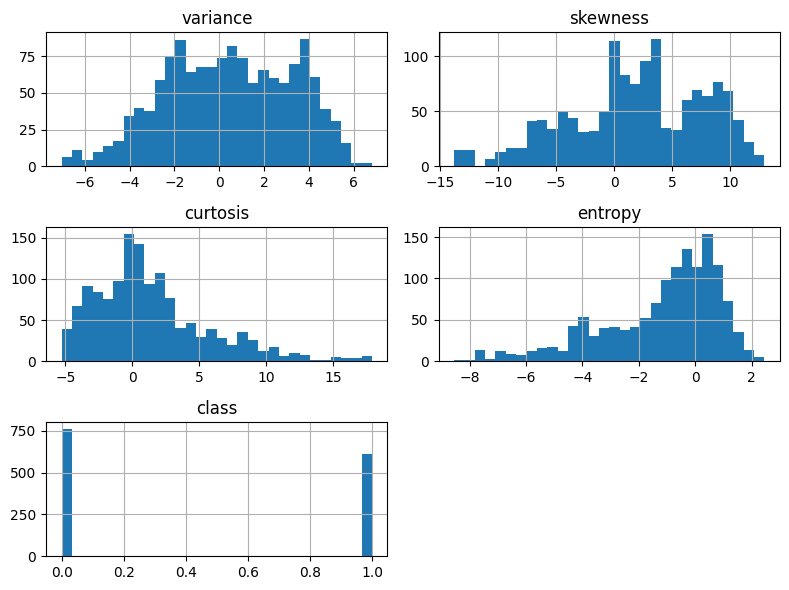

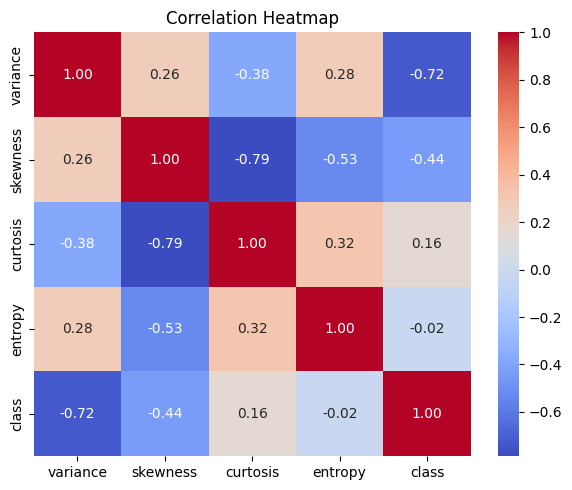

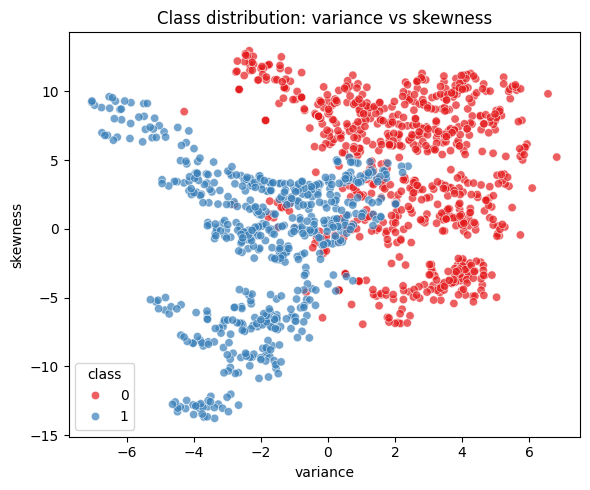

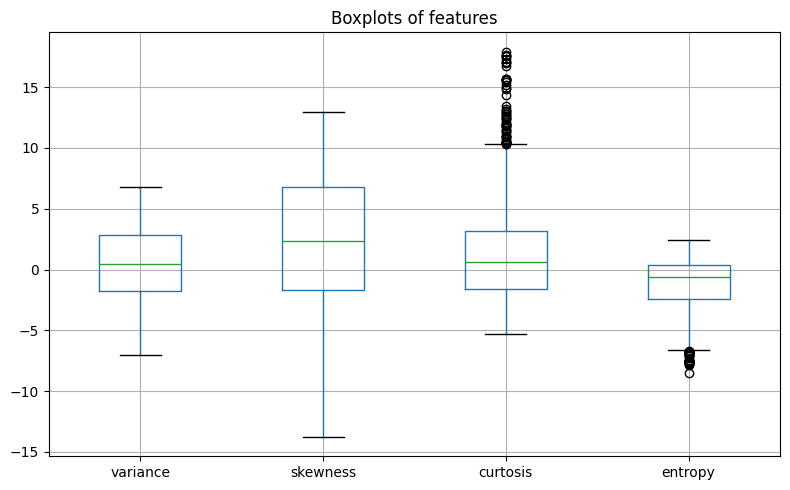

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
df.hist(figsize=(8, 6), bins=30)
plt.tight_layout()
plt.show()

# --- Correlation heatmap ---
plt.figure(figsize=(6, 5))          # <-- new figure, isolates its own 5 ticks
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# --- Scatter plot ---
plt.figure(figsize=(6, 5))          # <-- new figure again
sns.scatterplot(data=df, x="variance", y="skewness", hue="class", palette="Set1", alpha=0.7)
plt.title("Class distribution: variance vs skewness")
plt.tight_layout()
plt.show()

# --- Boxplots ---
plt.figure(figsize=(8, 5))          # <-- new figure: guarantees a clean 4-tick axes
df.drop(columns="class").boxplot()
plt.title("Boxplots of features")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[["variance", "skewness", "curtosis", "entropy"]].values
y = df["class"].values

# Standardize: mean 0, std 1 — puts all features on comparable scales
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# stratify=y keeps the ~56/44 class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, "Test:", X_test.shape)
# Train: (1097, 4)  Test: (275, 4)

Train: (1097, 4) Test: (275, 4)


In [ ]:
class Perceptron:
    def __init__(self, n_features, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = np.zeros(n_features)   # weight initialization
        self.b = 0.0                    # bias initialization
        self.history = []               # tracks (epoch, errors, weights, bias)

    def step(self, z):
        # Step activation function: f(z) = 1 if z>=0 else 0
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        z = X @ self.w + self.b          # forward propagation: z = w^T x + b
        return self.step(z)

    def fit(self, X, y, verbose=True):
        for epoch in range(1, self.epochs + 1):
            errors = 0
            for xi, target in zip(X, y):
                z = np.dot(xi, self.w) + self.b
                y_hat = 1 if z >= 0 else 0
                update = self.lr * (target - y_hat)   # η(y - ŷ)
                if update != 0:
                    self.w += update * xi             # w_new = w_old + η(y-ŷ)x
                    self.b += update                  # b_new = b_old + η(y-ŷ)
                    errors += 1
            self.history.append((epoch, errors, self.w.copy(), self.b))
            if verbose and (epoch <= 5 or epoch % 10 == 0):
                print(f"Epoch {epoch:3d} | Misclassified: {errors:3d} | "
                      f"w1={self.w[0]:.4f} w2={self.w[1]:.4f} b={self.b:.4f}")
            if errors == 0:
                print(f"Converged at epoch {epoch}")
                break
        return self

p = Perceptron(n_features=X_train.shape[1], lr=0.01, epochs=50)
p.fit(X_train, y_train)

Epoch   1 | Misclassified:  59 | w1=-0.0680 w2=-0.0938 b=-0.0300
Epoch   2 | Misclassified:  25 | w1=-0.0775 w2=-0.1042 b=-0.0400
Epoch   3 | Misclassified:  20 | w1=-0.0802 w2=-0.1127 b=-0.0400
Epoch   4 | Misclassified:  19 | w1=-0.0883 w2=-0.1196 b=-0.0500
Epoch   5 | Misclassified:  20 | w1=-0.0991 w2=-0.1295 b=-0.0500
Epoch  10 | Misclassified:  20 | w1=-0.1307 w2=-0.1541 b=-0.0600
Epoch  20 | Misclassified:  19 | w1=-0.1636 w2=-0.1946 b=-0.0700
Epoch  30 | Misclassified:  17 | w1=-0.1751 w2=-0.2043 b=-0.0800
Epoch  40 | Misclassified:  18 | w1=-0.1948 w2=-0.2244 b=-0.0900
Epoch  50 | Misclassified:  18 | w1=-0.1941 w2=-0.2358 b=-0.1000


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)

y_pred = p.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 score :", f1_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.9854545454545455
Precision: 0.9682539682539683
Recall   : 1.0
F1 score : 0.9838709677419355
Confusion matrix:
 [[149   4]
 [  0 122]]


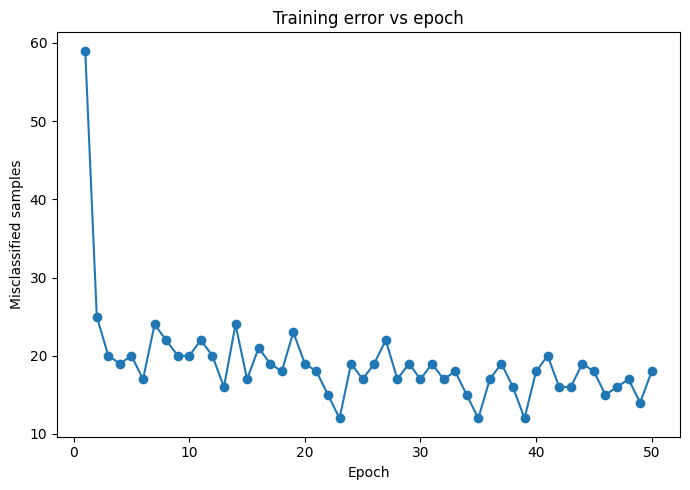

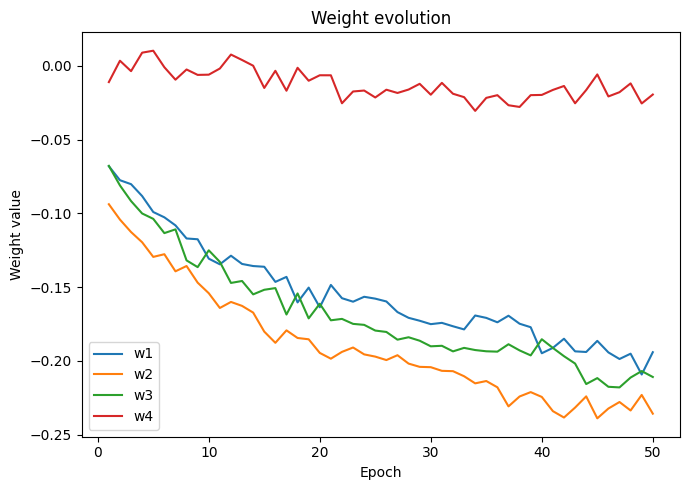

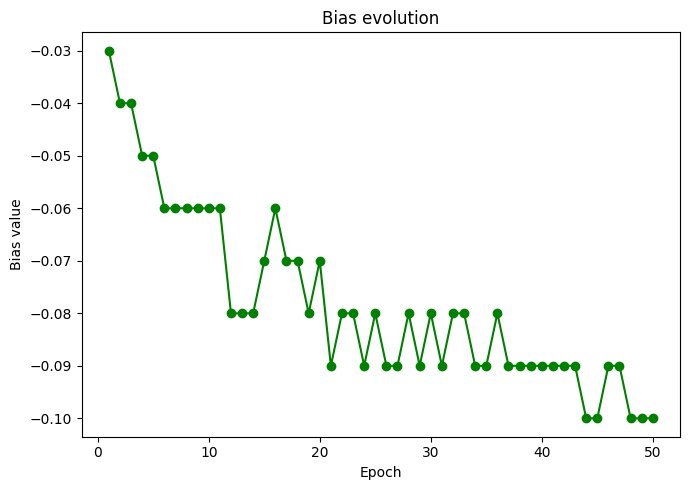

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set the font globaly — affects every plot's text after this line

# --- Training error vs epoch ---
epochs_ = [h[0] for h in p.history]
errors_ = [h[1] for h in p.history]

plt.figure(figsize=(7, 5))
plt.plot(epochs_, errors_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Misclassified samples")
plt.title("Training error vs epoch")
plt.tight_layout()
plt.show()

# --- Weight evolution: all 4 weights on ONE plot with a legend ---
w_hist = np.array([h[2] for h in p.history])   # shape: (epochs, n_features)

plt.figure(figsize=(7, 5))
for i in range(w_hist.shape[1]):
    plt.plot(epochs_, w_hist[:, i], label=f"w{i+1}")
plt.xlabel("Epoch")
plt.ylabel("Weight value")
plt.title("Weight evolution")
plt.legend()          # <-- moved OUTSIDE the loop, and plt.show() removed from inside it
plt.tight_layout()
plt.show()             # <-- one single show() call for the whole figure

# --- Bias evolution ---
b_hist = [h[3] for h in p.history]

plt.figure(figsize=(7, 5))
plt.plot(epochs_, b_hist, marker="o", color="green")
plt.xlabel("Epoch")
plt.ylabel("Bias value")
plt.title("Bias evolution")
plt.tight_layout()
plt.show()


In [ ]:
lr_results = {}
for lr in [0.001, 0.01, 0.1]:
    p_lr = Perceptron(n_features=X_train.shape[1], lr=lr, epochs=50)
    p_lr.fit(X_train, y_train, verbose=False)
    errs = [h[1] for h in p_lr.history]
    y_pred_lr = p_lr.predict(X_test)
    lr_results[lr] = {
        "final_train_errors": errs[-1],
        "test_accuracy": accuracy_score(y_test, y_pred_lr)
    }
for i in lr_results:
    print(i,lr_results[i])

0.001 {'final_train_errors': 18, 'test_accuracy': 0.9854545454545455}
0.01 {'final_train_errors': 18, 'test_accuracy': 0.9854545454545455}
0.1 {'final_train_errors': 18, 'test_accuracy': 0.9854545454545455}


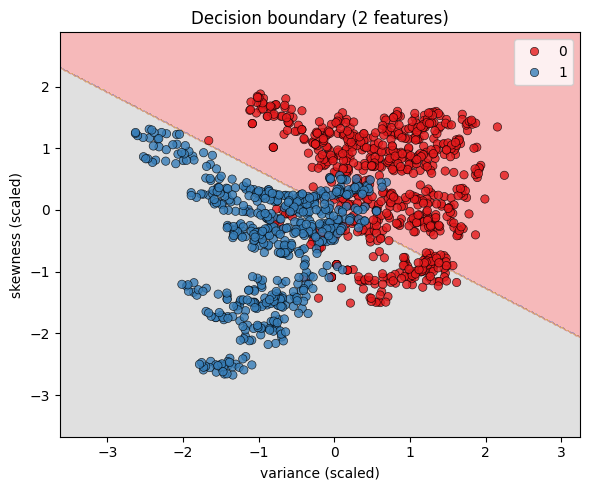

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Use only 2 features so the boundary can be drawn on a flat plane
X2 = X_scaled[:, :2]  # variance, skewness (columns 0 and 1)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y)

p2 = Perceptron(n_features=2, lr=0.01, epochs=50)
p2.fit(X2_train, y2_train, verbose=False)

# --- these were the missing lines ---
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
# -------------------------------------

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = p2.predict(grid).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="Set1")
sns.scatterplot(x=X2[:, 0], y=X2[:, 1], hue=y, palette="Set1", edgecolor="k", alpha=0.8)
plt.xlabel("variance (scaled)")
plt.ylabel("skewness (scaled)")
plt.title("Decision boundary (2 features)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import Perceptron as SkPerceptron

sk = SkPerceptron(eta0=0.01, max_iter=50, random_state=42)
sk.fit(X_train, y_train)
y_pred_sk = sk.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_sk))
print("Precision:", precision_score(y_test, y_pred_sk))
print("Recall   :", recall_score(y_test, y_pred_sk))
print("F1 score :", f1_score(y_test, y_pred_sk))

Accuracy : 0.9745454545454545
Precision: 0.9457364341085271
Recall   : 1.0
F1 score : 0.9721115537848606
